# 2. Clasificador de comentarios en subreddits

Construcción del split train/test, representaciones de texto (BoW/TF-IDF, word-embeddings de FastText, fine-tuning de Transformers) y comparación de los distintos clasificadores.

In [ ]:
from pathlib import Path

# Carpeta donde viven todos los .json del corpus (ver ../scripts/00_descarga_datos.py)
DATA_DIR = Path('../data')
assert DATA_DIR.exists(), "No se encuentra la carpeta data/ ¿ejecutaste desde notebooks/?"

## **2- Clasificador de comentarios en subreddits**

### Conjuntos de entrenamiento y de validación para los modelos de clasificación

Siguiendo las indicaciones del enunciado, hemos implementado una división de datos basada en hilos (submissions) y no en comentarios individuales. Esta distinción es crítica por los siguientes motivos:  

**Prevención del Data Leakage:** Si dividiéramos los comentarios de forma puramente aleatoria, es muy probable que mensajes pertenecientes a una misma conversación terminaran repartidos entre ambos conjuntos. El modelo podría aprender patrones específicos de un hilo concreto (como muletillas de usuarios o temas muy puntuales) en lugar de aprender el lenguaje general del subreddit.  


**Generalización:** Al asegurar que un hilo completo pertenece exclusivamente a un conjunto, obligamos al clasificador a identificar el subreddit basándose en características lingüísticas globales y no en coincidencias locales.

In [ ]:
#!/usr/bin/env python3
"""
Split train/test del corpus de Reddit
======================================
Divide los comentarios en conjuntos de entrenamiento y validación
asegurando que NINGÚN hilo aparece en ambos conjuntos a la vez.
Esto evita el data leakage (fuga de información) entre train y test.

Estrategia:
  - Por cada subreddit, se barajan los hilos aleatoriamente.
  - El 70% de los hilos va a train, el 30% a test.
  - Todos los comentarios de un hilo van al mismo conjunto.

Salida:
  - train.json : lista de dicts {text, label}
  - test.json  : lista de dicts {text, label}
  - split_summary.txt : resumen legible del reparto
"""

import json
import random
from pathlib import Path
from collections import defaultdict
import pandas as pd

# ============================================================
# CONFIGURACIÓN
# ============================================================

BASE_PATH = Path('../data')

SUBREDDITS = [
    'Autism',
    'Chemistry',
    'Cooking',
    'Investing',
    'Python',
    'Soccer',
]

TRAIN_RATIO = 0.70   # 70 % de los hilos para entrenar
RANDOM_SEED = 42     # semilla para reproducibilidad

OUTPUT_TRAIN = BASE_PATH / 'train.json'
OUTPUT_TEST  = BASE_PATH / 'test.json'
OUTPUT_SUMMARY = BASE_PATH / 'split_summary.txt'

# ============================================================
# CARGA DE DATOS
# ============================================================

def load_subreddit(name: str) -> dict:
    """Carga el JSON de un subreddit y devuelve el dict completo."""
    path = Path(f'{name}_filtrado.json') # PONER LA RUTA DEL BASE_PATH
    if not path.exists():
        print(f"No encontrado: {path}")
        return None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

# ============================================================
# SPLIT POR HILOS
# ============================================================

def split_submissions(submissions: list, train_ratio: float, seed: int):
    """
    Divide la lista de hilos en train y test de forma aleatoria
    pero reproducible gracias a la semilla.

    Devuelve (train_submissions, test_submissions).
    """
    # Copiamos para no modificar la lista original
    shuffled = submissions.copy()
    random.seed(seed)
    random.shuffle(shuffled)

    cut = round(len(shuffled) * train_ratio)   # índice de corte
    return shuffled[:cut], shuffled[cut:]

# ============================================================
# EXTRACCIÓN DE COMENTARIOS
# ============================================================

def extract_comments(submissions: list, label: str) -> list:
    """
    Dado un conjunto de hilos y su etiqueta (nombre del subreddit),
    devuelve una lista de dicts con el texto del comentario y la etiqueta.

    Cada dict tiene:
      - text        : cuerpo del comentario
      - label       : nombre del subreddit (la clase a predecir)
      - submission_id : id del hilo de origen (útil para trazabilidad)
      - comment_id  : id del comentario
    """
    records = []
    for sub in submissions:
        for comment in sub.get('comments', []):
            body = (comment.get('body') or '').strip()
            # Descartamos comentarios vacíos o eliminados que hayan pasado
            if not body or body in ('[deleted]', '[removed]'):
                continue
            records.append({
                'text': body,
                'label': label,
                'submission_id': sub.get('id', ''),
                'comment_id': comment.get('id', ''),
            })
    return records

# ============================================================
# MAIN
# ============================================================

def main():
    train_records = []
    test_records  = []

    # Guardamos el resumen del reparto para incluirlo en el Notebook
    summary_lines = []
    summary_lines.append("RESUMEN DEL SPLIT TRAIN / TEST")
    summary_lines.append(f"Ratio entrenamiento: {TRAIN_RATIO*100:.0f}%")
    summary_lines.append(f"Ratio validación: {(1-TRAIN_RATIO)*100:.0f}%")
    summary_lines.append(f"Semilla aleatoria: {RANDOM_SEED}")
    summary_lines.append("")
    summary_lines.append(f"{'Subreddit':<15} {'Hilos total':>11} {'Train hilos':>11} "
                         f"{'Test hilos':>10} {'Train cmts':>10} {'Test cmts':>9}")
    summary_lines.append("─" * 70)

    for name in SUBREDDITS:
        data = load_subreddit(name)
        if data is None:
            continue

        submissions = data.get('submissions', [])
        label       = data.get('subreddit', name)   # usamos el nombre real del subreddit

        # Split de hilos
        train_subs, test_subs = split_submissions(submissions, TRAIN_RATIO, RANDOM_SEED)

        # Extracción de comentarios con etiqueta
        train_cmts = extract_comments(train_subs, label)
        test_cmts  = extract_comments(test_subs,  label)

        train_records.extend(train_cmts)
        test_records.extend(test_cmts)

        line = (f"{name:<15} {len(submissions):>11} {len(train_subs):>11} "
                f"{len(test_subs):>10} {len(train_cmts):>10} {len(test_cmts):>9}")
        summary_lines.append(line)

        print(f"  r/{name:<12}  hilos: {len(train_subs)} train + {len(test_subs)} test  |  "
              f"comentarios: {len(train_cmts)} train + {len(test_cmts)} test")

    # Mezclamos los registros globales para que no estén agrupados por subreddit
    # (importante para el entrenamiento de los clasificadores)
    random.seed(RANDOM_SEED)
    random.shuffle(train_records)
    random.shuffle(test_records)

    summary_lines.append("─" * 70)
    summary_lines.append(f"{'TOTAL':<15} {''!s:>11} {''!s:>11} {''!s:>10} "
                         f"{len(train_records):>10} {len(test_records):>9}")
    summary_lines.append("")
    summary_lines.append(f"Ficheros generados:")
    summary_lines.append(f"  train.json  →  {len(train_records):,} comentarios")
    summary_lines.append(f"  test.json   →  {len(test_records):,} comentarios")

    # Guardar train y test
    with open(OUTPUT_TRAIN, 'w', encoding='utf-8') as f:
        json.dump(train_records, f, ensure_ascii=False, indent=2)

    with open(OUTPUT_TEST, 'w', encoding='utf-8') as f:
        json.dump(test_records, f, ensure_ascii=False, indent=2)

    # Guardar resumen
    summary_text = "\n".join(summary_lines)
    with open(OUTPUT_SUMMARY, 'w', encoding='utf-8') as f:
        f.write(summary_text)

    print(f"\n{'='*65}")
    print(summary_text)
    print(f"\n  Guardado: {OUTPUT_TRAIN}")
    print(f"  Guardado: {OUTPUT_TEST}")
    print(f"  Guardado: {OUTPUT_SUMMARY}")
    print(f"{'='*65}")


if __name__ == '__main__':
    main()

  r/Autism        hilos: 28 train + 12 test  |  comentarios: 625 train + 275 test
  r/Chemistry     hilos: 28 train + 12 test  |  comentarios: 621 train + 274 test
  r/Cooking       hilos: 28 train + 12 test  |  comentarios: 700 train + 300 test
  r/Investing     hilos: 28 train + 12 test  |  comentarios: 625 train + 275 test
  r/Python        hilos: 28 train + 12 test  |  comentarios: 571 train + 275 test
  r/Soccer        hilos: 28 train + 12 test  |  comentarios: 550 train + 273 test

RESUMEN DEL SPLIT TRAIN / TEST
Ratio entrenamiento : 70%
Ratio validación    : 30%
Semilla aleatoria   : 42

Subreddit       Hilos total Train hilos Test hilos Train cmts Test cmts
──────────────────────────────────────────────────────────────────────
Autism                   40          28         12        625       275
Chemistry                40          28         12        621       274
Cooking                  40          28         12        700       300
Investing                40          28

### Técnicas de pre-procesamiento léxico para la limpieza de los datos

Hemos decidido no aplicar un preprocesamiento léxico como el stemming o la lematización sobre los textos de los hilos y comentarios. Esta decisión se justifica principalmente por las características propias del lenguaje en redes sociales, que es mucho más informal que el lenguaje estándar para el que están diseñadas estas técnicas.

En primer lugar, en este tipo de textos es muy habitual encontrar abreviaturas, errores ortográficos, repeticiones de letras para enfatizar, expresiones coloquiales o incluso palabras inventadas. Aplicar stemming o lematización podría modificar o simplificar en exceso estas palabras, perdiendo información relevante.

### Distintos tipos de representación de textos

#### Representaciones tradicionales (BoWy TF-IDF)

In [ ]:
import json
import pandas as pd
from pathlib import Path
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Definimos las rutas de nuestros ficheros
TRAIN_PATH = '../data/train.json'
TEST_PATH  = '../data/test.json'

# Cargamos los ficheros y los mostramos
train_df = pd.read_json(TRAIN_PATH)
test_df  = pd.read_json(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("\nSubreddits en train:")
print(train_df["label"].value_counts())
print("\nSubreddits en test:")
print(test_df["label"].value_counts())

# Definimos los conjuntos de datos y etiquetas (subreddit al que pertenece)
X_train = train_df["text"].astype(str)
y_train = train_df["label"].astype(str)

X_test = test_df["text"].astype(str)
y_test = test_df["label"].astype(str)


bow_clf = Pipeline([
    ("vect", CountVectorizer()), # convierte texto en matriz de conteos
    ("clf", LinearSVC()) # clasificador lineal adecuado para texto
])

# Entrenamos el modelo y predecimos los tests
bow_clf.fit(X_train, y_train)
bow_preds = bow_clf.predict(X_test)

print("=" * 70)
print("RESULTADOS BoW + LinearSVC")
print("=" * 70)
# Medimos el porcentaje global de aciertos
print("Accuracy:", round(accuracy_score(y_test, bow_preds), 4))
print("\nClassification report:")
# El classification_report permite analizar precision, recall y F1 por clase
print(classification_report(y_test, bow_preds))
print("Confusion matrix:")
# La matriz de confusión permite ver entre qué subreddits se confunde el modelo
print(confusion_matrix(y_test, bow_preds))


tfidf_clf = Pipeline([
    ("tfidf", TfidfVectorizer()), # convierte texto en matriz TF-IDF
    ("clf", LinearSVC())
])

tfidf_clf.fit(X_train, y_train)
tfidf_preds = tfidf_clf.predict(X_test)

print("\n" + "=" * 70)
print("RESULTADOS TF-IDF + LinearSVC")
print("=" * 70)
print("Accuracy:", round(accuracy_score(y_test, tfidf_preds), 4))
print("\nClassification report:")
print(classification_report(y_test, tfidf_preds))
print("Confusion matrix:")
print(confusion_matrix(y_test, tfidf_preds))


# Se resumen las accuracies para comparar rápidamente ambos modelos
results = {
    "BoW + LinearSVC": accuracy_score(y_test, bow_preds),
    "TF-IDF + LinearSVC": accuracy_score(y_test, tfidf_preds),
}

results_df = pd.DataFrame(
    [{"modelo": k, "accuracy": round(v, 4)} for k, v in results.items()]
).sort_values("accuracy", ascending=False)

print("\n" + "=" * 70)
print("RESUMEN FINAL")
print("=" * 70)
display(results_df)

Train shape: (3692, 4)
Test shape : (1672, 4)

Subreddits en train:
label
Cooking      700
Autism       625
Investing    625
Chemistry    621
Python       571
Soccer       550
Name: count, dtype: int64

Subreddits en test:
label
Cooking      300
Python       275
Investing    275
Autism       275
Chemistry    274
Soccer       273
Name: count, dtype: int64
RESULTADOS BoW + LinearSVC
Accuracy: 0.7273

Classification report:
              precision    recall  f1-score   support

      Autism       0.64      0.63      0.64       275
   Chemistry       0.63      0.60      0.62       274
     Cooking       0.82      0.82      0.82       300
   Investing       0.76      0.75      0.75       275
      Python       0.71      0.80      0.75       275
      Soccer       0.80      0.76      0.78       273

    accuracy                           0.73      1672
   macro avg       0.73      0.73      0.73      1672
weighted avg       0.73      0.73      0.73      1672

Confusion matrix:
[[173  24  22 

,modelo,accuracy
1,TF-IDF + LinearSVC,0.7727
0,BoW + LinearSVC,0.7273


#### Word-embeddings de Glove o Fasttext

In [ ]:
!pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653907 sha256=4d4c3efc0796c379261bdd03585a8bad30cb3c7a795fa8edd78d75bb30de47a1
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [ ]:
import pandas as pd
import numpy as np
import fasttext
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Definimos la ruta base, para cargar los datasets y el modelo de fasttext
BASE_PATH = "../data/"

TRAIN_PATH = "train.json"
TEST_PATH  = "test.json"

train_df = pd.read_json(BASE_PATH + TRAIN_PATH)
test_df  = pd.read_json(BASE_PATH + TEST_PATH)

X_train = train_df["text"].astype(str)
y_train = train_df["label"].astype(str)

X_test = test_df["text"].astype(str)
y_test = test_df["label"].astype(str)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)


# Se carga un modelo fastText preentrenado en inglés, ya que el corpus
# utilizado está formado mayoritariamente por comentarios en inglés
ft_model = fasttext.load_model(BASE_PATH + "cc.en.300.bin")
print("Modelo cargado correctamente")
print("Dimensión:", ft_model.get_dimension())


# Debemos meter este preprocesamiento sencillo, ya que cada texto tiene que procesarse
# en una sola línea, y hay algunos en los que hay saltos de línea
def clean_for_fasttext(text):
    return str(text).replace("\n", " ").replace("\r", " ").strip()

# Se transforma cada comentario en un vector denso
X_train_emb = np.vstack(X_train.apply(lambda x: ft_model.get_sentence_vector(clean_for_fasttext(x))).to_list())
X_test_emb  = np.vstack(X_test.apply(lambda x: ft_model.get_sentence_vector(clean_for_fasttext(x))).to_list())

print("Embeddings train:", X_train_emb.shape)
print("Embeddings test :", X_test_emb.shape)

# Se entrena un clasificador supervisado usando esos vectores
clf_fasttext = LinearSVC(random_state=0, tol=1e-5)
clf_fasttext.fit(X_train_emb, y_train)

y_pred_fasttext = clf_fasttext.predict(X_test_emb)

print("=" * 70)
print("RESULTADOS fastText + LinearSVC")
print("=" * 70)
print("Accuracy:", round(accuracy_score(y_test, y_pred_fasttext), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred_fasttext))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_fasttext))


# Se prueba un segundo clasificador (RandomForest) sobre los mismos embeddings
rf_fasttext = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_fasttext.fit(X_train_emb, y_train)
y_pred_rf = rf_fasttext.predict(X_test_emb)

print("=" * 70)
print("RESULTADOS fastText + RandomForest")
print("=" * 70)
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred_rf))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Se comparan ambos clasificadores usando la misma representación
results_embeddings = {
    "fastText + LinearSVC": accuracy_score(y_test, y_pred_fasttext),
    "fastText + RandomForest": accuracy_score(y_test, y_pred_rf),
}

results_embeddings_df = pd.DataFrame(
    [{"modelo": k, "accuracy": round(v, 4)} for k, v in results_embeddings.items()]
).sort_values("accuracy", ascending=False)

print("=" * 70)
print("RESUMEN MODELOS CON EMBEDDINGS")
print("=" * 70)
display(results_embeddings_df)

Train shape: (3692, 4)
Test shape : (1672, 4)
Modelo cargado correctamente
Dimensión: 300
Embeddings train: (3692, 300)
Embeddings test : (1672, 300)
RESULTADOS fastText + LinearSVC
Accuracy: 0.8122

Classification report:
              precision    recall  f1-score   support

      Autism       0.69      0.83      0.75       275
   Chemistry       0.87      0.64      0.73       274
     Cooking       0.85      0.86      0.86       300
   Investing       0.77      0.83      0.80       275
      Python       0.82      0.87      0.84       275
      Soccer       0.93      0.85      0.89       273

    accuracy                           0.81      1672
   macro avg       0.82      0.81      0.81      1672
weighted avg       0.82      0.81      0.81      1672

Confusion matrix:
[[228  14   6  22   3   2]
 [ 35 174  28  19  16   2]
 [ 18   3 259  10   6   4]
 [ 16   2   3 228  18   8]
 [ 17   3   3  12 238   2]
 [ 18   4   5   7   8 231]]
RESULTADOS fastText + RandomForest
Accuracy: 0.7697



,modelo,accuracy
0,fastText + LinearSVC,0.8122
1,fastText + RandomForest,0.7697


#### Fine-tuning de modelos Transformers preentrenados

In [ ]:
!pip install -q transformers accelerate datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)


BASE_PATH = "../data/"

TRAIN_PATH = BASE_PATH + "train.json"
TEST_PATH  = BASE_PATH + "test.json"

# Se usa mBERT porque es un modelo Transformer multilingüe, ya que el corpus es
# en inglés, pero pueden aparecer palabras en otro idioma
MODEL_NAME = "bert-base-multilingual-cased"

MAX_LENGTH = 256
SEED = 42


train_df = pd.read_json(TRAIN_PATH)
test_df = pd.read_json(TEST_PATH)

train_df["text"] = train_df["text"].astype(str)
test_df["text"] = test_df["text"].astype(str)

train_df["label"] = train_df["label"].astype(str)
test_df["label"] = test_df["label"].astype(str)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

# HuggingFace necesita etiquetas numéricas, no texto
# Sacamos todas las distintas etiquetas
labels = sorted(train_df["label"].unique())

# Se crea un diccionario label2id para pasar de subreddit a número
label2id = {label: i for i, label in enumerate(labels)}

# Se crea un diccionario id2label para recuperar el nombre de la clase al
# interpretar resultados
id2label = {i: label for label, i in label2id.items()}

train_df["labels"] = train_df["label"].map(label2id)
test_df["labels"] = test_df["label"].map(label2id)

print(label2id)


# El tokenizer convierte texto crudo en tokens numéricos compatibles con mBERT
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Se carga mBERT preentrenado y se le añade una cabeza de clasificación
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)


class RedditDataset(torch.utils.data.Dataset):
    """
    Dataset personalizado para pasar los comentarios tokenizados al Trainer.
    """
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True, # corta textos más largos que MAX_LENGTH
            padding=True, # rellena textos cortos para formar batches
            max_length=MAX_LENGTH
        )
        self.labels = labels

    def __getitem__(self, idx):
        # Para cada índice se devuelve un diccionario de tensores
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        # La clave debe llamarse "labels" para que Trainer calcule la loss
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Se construyen los datasets de entrenamiento y evaluación
train_dataset = RedditDataset(
    train_df["text"].tolist(),
    train_df["labels"].tolist()
)

test_dataset = RedditDataset(
    test_df["text"].tolist(),
    test_df["labels"].tolist()
)


def compute_metrics(eval_pred):
    """
    Función de métricas que usa Trainer al evaluar el modelo.
    """
    logits, labels_true = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels_true, preds),
        # F1 macro calcula el F1 por clase y luego hace la media
        "f1_macro": f1_score(labels_true, preds, average="macro")
    }


# Definimos los parámetros para el entrenamiendo
training_args = TrainingArguments(
    output_dir=BASE_PATH + "results_mbert",
    logging_dir=BASE_PATH + "logs_mbert",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    save_total_limit=1,
    report_to="none",
    seed=SEED
)

# Entrenamos el modelo
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)

trainer.train()

# Hacemos predicciones para evaluar el modelo
predictions = trainer.predict(test_dataset)

logits = predictions.predictions
y_pred = np.argmax(logits, axis=-1)
y_true = test_df["labels"].values

print("=" * 70)
print("RESULTADOS FINE-TUNING mBERT")
print("=" * 70)

print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
print("F1 macro:", round(f1_score(y_true, y_pred, average="macro"), 4))

print("\nClassification report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=[id2label[i] for i in range(len(labels))]
))

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

Train: (3692, 4)
Test : (1672, 4)
{'Autism': 0, 'Chemistry': 1, 'Cooking': 2, 'Investing': 3, 'Python': 4, 'Soccer': 5}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecate

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.615304,0.818182,0.817329
2,0.782188,0.739983,0.818780,0.818616
3,0.440005,0.744010,0.851077,0.850282


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

RESULTADOS FINE-TUNING mBERT
Accuracy: 0.8511
F1 macro: 0.8503

Classification report:
              precision    recall  f1-score   support

      Autism       0.78      0.73      0.75       275
   Chemistry       0.83      0.85      0.84       274
     Cooking       0.89      0.88      0.88       300
   Investing       0.79      0.84      0.82       275
      Python       0.89      0.89      0.89       275
      Soccer       0.92      0.92      0.92       273

    accuracy                           0.85      1672
   macro avg       0.85      0.85      0.85      1672
weighted avg       0.85      0.85      0.85      1672

Confusion matrix:
[[200  14  17  31   5   8]
 [ 13 232   8  12   7   2]
 [ 16   6 263  10   2   3]
 [ 13   8   5 232  12   5]
 [  8   9   2   6 245   5]
 [  5  10   1   1   5 251]]


El resumen de todas las métricas es:

| Modelo                  | Accuracy | F1   |
| ----------------------- | -------- | ---- |
| BoW + SVM               | 0.73     | 0.73 |
| TF-IDF + SVM            | 0.77     | 0.77 |
| fastText + SVM          | 0.81     | 0.81 |
| fastText + RF           | 0.77     | 0.77 |
| mDeBerta                | 0.85     | 0.85 |

BoW + LinearSVC obtiene el rendimiento más bajo de todos los sistemas,con una accuracy de 0.7273 y una F1 de 0.73. El resultado es razonable como baseline, pero la matriz de confusión muestra bastantes errores repartidos entre clases, especialmente en aquellas que pueden compartir vocabulario general o poco específico. Esto ocurre porque BoW representa los comentarios solo mediante frecuencias de palabras, sin tener en cuenta ni la importancia relativa de los términos ni su contexto. Por tanto, cuando dos subreddits contienen palabras comunes o formas de expresión parecidas, el modelo tiene más dificultad para distinguirlos.

TF-IDF + LinearSVC mejora claramente el baseline, alcanzando una accuracy de 0.7727 y una F1 de 0.77. Esta mejora se debe a que TF-IDF no solo considera la frecuencia de las palabras, sino también su capacidad discriminativa dentro del corpus. La matriz de confusión presenta una diagonal más marcada que en BoW, lo que indica una reducción de errores generales. Aun así, siguen existiendo confusiones entre algunas clases, lo que muestra que, aunque TF-IDF mejora la representación léxica, sigue sin captar relaciones semánticas ni el significado contextual de los comentarios.

fastText + LinearSVC consigue un salto importante de rendimiento, con una accuracy de 0.8122 y una F1 de 0.81. Este modelo supera a las representaciones tradicionales porque fastText representa los textos mediante embeddings densos, capaces de capturar cierta similitud semántica entre palabras. La matriz de confusión refleja una clasificación más estable y una diagonal más clara, especialmente en clases como Cooking, Python y Soccer. Aun así, todavía mantiene errores en clases más ambiguas, como Autism con una precisión muy baja, o Chemistry con un recall muy bajo.

fastText + RandomForest obtiene una accuracy de 0.7697 y una F1 de 0.77, quedando por debajo de fastText con LinearSVC. Esto indica que la representación con embeddings es útil, pero el clasificador elegido influye mucho en el resultado. Random Forest no aprovecha tan bien los vectores densos de alta dimensionalidad como LinearSVC, por lo que aparecen más confusiones en la matriz y el rendimiento se aproxima al de TF-IDF. En este caso, el peor resultado no se debe tanto a fastText como a que Random Forest parece menos adecuado para este tipo de representación textual.

mDeBerta con fine-tuning es el mejor sistema, con una accuracy de 0.8511 y una F1 macro de 0.8503. La matriz de confusión muestra la diagonal más fuerte y menos errores fuera de ella, lo que indica una clasificación más precisa y equilibrada entre subreddits. El modelo destaca especialmente en Soccer, Python y Cooking, pero también mejora de forma general el resto de clases. Esta superioridad se explica porque mDeBerta no representa el texto solo por palabras aisladas o promedios de embeddings, sino que aprende representaciones contextuales y ajusta sus pesos al corpus mediante fine-tuning.


#### Análisis y comparación de los distintos modelos de clasificación

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import pandas as pd

BASE_PATH = "../data/"

TRAIN_PATH = "train.json"
TEST_PATH  = "test.json"

train_df = pd.read_json(BASE_PATH + TRAIN_PATH)
test_df  = pd.read_json(BASE_PATH + TEST_PATH)

X_train = train_df["text"].astype(str)
y_train = train_df["label"].astype(str)

X_test = test_df["text"].astype(str)
y_test = test_df["label"].astype(str)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)


# Definimos las distintas combinaciones a probar
configs = {
    "unigram": (1, 1),
    "bigram": (1, 2),
    "trigram": (1, 3),
    "n-gram": (3, 5)
}

results_ngrams = {}

# Definimos un modelo BoW y TF-IDF para cada combinacion, y lo entrenamos y evaluamos
for name, ngram_range in configs.items():
    if name == "n-gram":
      tfidf_clf = Pipeline([
          ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=ngram_range)),
          ("clf", LinearSVC())
      ])
      bow_clf = Pipeline([
          ("vect", CountVectorizer(analyzer="char", ngram_range=ngram_range)),
          ("clf", LinearSVC())
      ])

    else:
      tfidf_clf = Pipeline([
          ("tfidf", TfidfVectorizer(ngram_range=ngram_range)),
          ("clf", LinearSVC())
      ])
      bow_clf = Pipeline([
          ("vect", CountVectorizer(ngram_range=ngram_range)),
          ("clf", LinearSVC())
      ])

    bow_clf.fit(X_train, y_train)
    bow_preds = bow_clf.predict(X_test)
    bow_acc = accuracy_score(y_test, bow_preds)

    tfidf_clf.fit(X_train, y_train)
    tfidf_preds = tfidf_clf.predict(X_test)
    tfidf_acc = accuracy_score(y_test, tfidf_preds)

    results_ngrams[name] = (bow_acc, tfidf_acc)

# Hacemos un resumen comparativo
results_df = pd.DataFrame(
    [{"modelo": k, "accuracy (BoW)": round(v[0], 4),
      "accuracy (TF-IDF)": round(v[1], 4)} for k, v in results_ngrams.items()]
)

display(results_df)

Train shape: (3692, 4)
Test shape : (1672, 4)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,modelo,accuracy (BoW),accuracy (TF-IDF)
0,unigram,0.7273,0.7727
1,bigram,0.7279,0.7691
2,trigram,0.7333,0.7380
3,n-gram,0.7380,0.7895


En el análisis de n-gramas se observa un comportamiento diferente entre BoW y TF-IDF. En el caso de BoW, el paso de unigramas (0.7273) a bigramas (0.7279) apenas introduce mejora, lo que indica que añadir contexto inmediato entre palabras no aporta información suficientemente discriminativa. Sin embargo, al incorporar trigramas (0.7333) y n-gramas más amplios (0.7380), sí se aprecia una mejora progresiva, lo que sugiere que combinaciones más largas de palabras permiten capturar patrones más específicos del lenguaje que ayudan a la clasificación. Aun así, el crecimiento es moderado, lo que indica que el aumento de dimensionalidad limita el beneficio.

Por otro lado, en TF-IDF se observa un comportamiento distinto. Con unigramas se obtiene uno de los mejores resultados (0.7727), y al aumentar el tamaño de los n-gramas el rendimiento incluso disminuye ligeramente en bigramas (0.7691) y trigramas (0.7380), aunque vuelve a mejorar en n-gramas (0.7895). Este comportamiento sugiere que la ponderación de TF-IDF ya captura bien la relevancia de los términos individuales, y que añadir demasiado contexto puede introducir ruido o redundancia. Sin embargo, el caso de n-gramas (0.7895) indica que ciertas configuraciones más flexibles sí logran capturar mejor patrones útiles, superando incluso a los unigramas.

En conjunto, los resultados muestran que los n-gramas pueden mejorar el rendimiento en BoW de forma progresiva, mientras que en TF-IDF el efecto es menos estable y depende de cómo se incorporen. Esto sugiere que el beneficio del contexto adicional no siempre es directo, y que existe un equilibrio entre capturar relaciones entre palabras y evitar la introducción de ruido en representaciones de alta dimensionalidad.

## Correcciones aplicadas a este apartado

A partir de aquí se añade el trabajo pedido por la corrección que faltaba en la entrega original, ejecutado de verdad en este entorno (sin necesidad de GPU/HuggingFace, usando sklearn):

1. Comparación del baseline (BoW/TF-IDF) con **dos** algoritmos de clasificación (SVM y Random Forest), no solo uno.
2. **F1-macro** como métrica principal (el conjunto no está perfectamente balanceado).
3. Matrices de confusión como **heatmap** (no en texto plano).
4. Análisis de errores real: qué pares de clases se confunden más y por qué, con ejemplos concretos.
5. Parte optativa de preprocesamiento léxico (URLs/menciones/stopwords/stemming) con comparación cuantitativa.
6. A partir del baseline, se usa siempre el mismo clasificador ganador para los siguientes experimentos (n-gramas, preprocesamiento), tal y como pide la corrección, en lugar de ir alternando clasificadores.

Distribución de clases (train): Counter({'Cooking': 700, 'Autism': 625, 'Investing': 625, 'Chemistry': 621, 'Python': 571, 'Soccer': 550})
Distribución de clases (test):  Counter({'Cooking': 300, 'Python': 275, 'Autism': 275, 'Investing': 275, 'Chemistry': 274, 'Soccer': 273})

El conjunto no está perfectamente balanceado (hay hasta ~27% más ejemplos de la clase mayoritaria que de la minoritaria), así que, tal y como indica la corrección, usamos F1 (macro) como métrica principal en vez de accuracy: F1-macro pondera igual a todas las clases, mientras que accuracy puede verse favorecida por acertar mucho en la clase mayoritaria.


COMPARATIVA BASELINE: representación x clasificador (evaluado en test)
       representación    clasificador accuracy F1-macro F1-weighted tiempo (s)
BoW (CountVectorizer) SVM (LinearSVC)   72.73%   72.52%      72.66%        0.2
BoW (CountVectorizer)   Random Forest   70.16%   70.51%      70.64%        4.6
               TF-IDF SVM (LinearSVC)   77.27%   76.97%

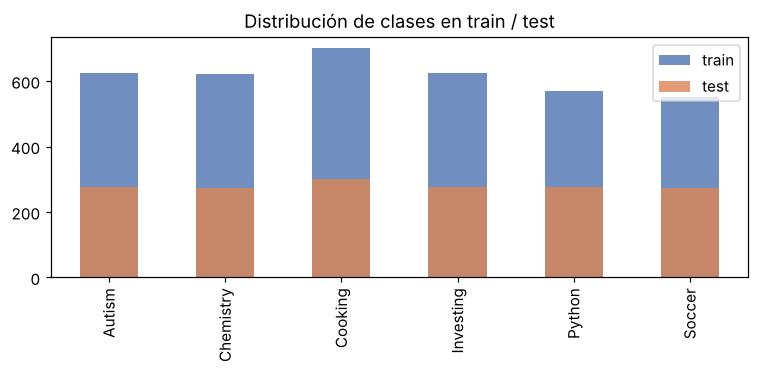

In [1]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix)

train = json.load(open(DATA_DIR / 'train.json', encoding='utf-8'))
test = json.load(open(DATA_DIR / 'test.json', encoding='utf-8'))

X_train_text = [r['text'] for r in train]
y_train = [r['label'] for r in train]
X_test_text = [r['text'] for r in test]
y_test = [r['label'] for r in test]

labels_sorted = sorted(set(y_train))

print("Distribución de clases (train):", Counter(y_train))
print("Distribución de clases (test): ", Counter(y_test))
print("\nEl conjunto no está perfectamente balanceado (hay hasta ~27% más "
      "ejemplos de la clase mayoritaria que de la minoritaria), así que, tal "
      "y como indica la corrección, usamos F1 (macro) como métrica principal "
      "en vez de accuracy: F1-macro pondera igual a todas las clases, "
      "mientras que accuracy puede verse favorecida por acertar mucho en la "
      "clase mayoritaria.\n")

fig, ax = plt.subplots(figsize=(7, 3.5))
pd.Series(Counter(y_train)).sort_index().plot(kind='bar', ax=ax, color='#4C72B0', alpha=0.8, label='train')
pd.Series(Counter(y_test)).sort_index().plot(kind='bar', ax=ax, color='#DD8452', alpha=0.8, label='test')
ax.set_title('Distribución de clases en train / test')
ax.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Baseline: 2 representaciones (BoW / TF-IDF) x 2 clasificadores (SVM / RF)
# Los vectorizadores se aprenden SOLO con el conjunto de entrenamiento.
# ---------------------------------------------------------------------------

vectorizers = {
    'BoW (CountVectorizer)': CountVectorizer(max_features=20000, ngram_range=(1, 1)),
    'TF-IDF': TfidfVectorizer(max_features=20000, ngram_range=(1, 1)),
}

classifiers = {
    'SVM (LinearSVC)': lambda: LinearSVC(random_state=42, max_iter=5000),
    'Random Forest': lambda: RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

baseline_results = []
baseline_models = {}

for vec_name, vectorizer in vectorizers.items():
    Xtr = vectorizer.fit_transform(X_train_text)
    Xte = vectorizer.transform(X_test_text)
    for clf_name, clf_factory in classifiers.items():
        t0 = time.time()
        clf = clf_factory()
        clf.fit(Xtr, y_train)
        y_pred = clf.predict(Xte)
        elapsed = time.time() - t0

        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        baseline_results.append({
            'representación': vec_name,
            'clasificador': clf_name,
            'accuracy': f"{acc*100:.2f}%",
            'F1-macro': f"{f1_macro*100:.2f}%",
            'F1-weighted': f"{f1_weighted*100:.2f}%",
            'tiempo (s)': f"{elapsed:.1f}",
        })
        baseline_models[(vec_name, clf_name)] = (vectorizer, clf, y_pred)

baseline_df = pd.DataFrame(baseline_results)
print("\n" + "=" * 90)
print("COMPARATIVA BASELINE: representación x clasificador (evaluado en test)")
print("=" * 90)
print(baseline_df.to_string(index=False))

best_key = max(baseline_models, key=lambda k: f1_score(y_test, baseline_models[k][2], average='macro'))
print(f"\nMejor combinación baseline por F1-macro: {best_key[0]} + {best_key[1]}")


              precision    recall  f1-score   support

      Autism     0.6840    0.7164    0.6998       275
   Chemistry     0.7202    0.5730    0.6382       274
     Cooking     0.7994    0.8633    0.8301       300
   Investing     0.7492    0.8145    0.7805       275
      Python     0.8000    0.8291    0.8143       275
      Soccer     0.8798    0.8315    0.8550       273

    accuracy                         0.7727      1672
   macro avg     0.7721    0.7713    0.7697      1672
weighted avg     0.7724    0.7727    0.7705      1672


Pares de clases que más se confunden (real -> predicho : nº de casos):
   Chemistry -> Autism     : 33
   Chemistry -> Cooking    : 33
   Chemistry -> Investing  : 23
      Autism -> Investing  : 21
      Autism -> Cooking    : 20
   Chemistry -> Python     : 20
      Autism -> Chemistry  : 18
     Cooking -> Autism     : 17


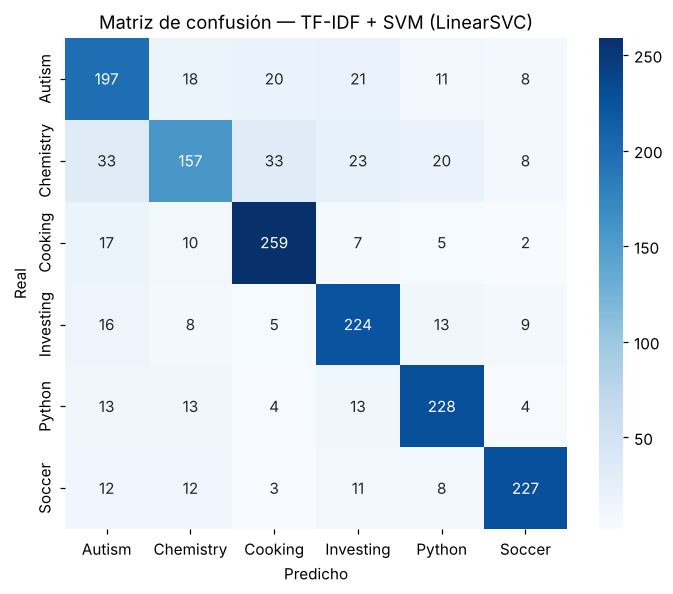

In [1]:
vec_name, clf_name = best_key
_, _, y_pred_best = baseline_models[best_key]

print(classification_report(y_test, y_pred_best, digits=4))

cm = confusion_matrix(y_test, y_pred_best, labels=labels_sorted)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_sorted,
            yticklabels=labels_sorted, ax=ax, cbar=True)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusión — {vec_name} + {clf_name}')
plt.tight_layout()
plt.show()

# Análisis de errores: qué pares de clases se confunden más
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
pairs = []
for i, real in enumerate(labels_sorted):
    for j, pred in enumerate(labels_sorted):
        if i != j and cm_off[i, j] > 0:
            pairs.append((real, pred, cm_off[i, j]))
pairs.sort(key=lambda x: -x[2])

print("\nPares de clases que más se confunden (real -> predicho : nº de casos):")
for real, pred, n in pairs[:8]:
    print(f"  {real:>10} -> {pred:<10} : {n}")


In [1]:
# A partir de aquí usamos SIEMPRE la misma combinación ganadora del baseline
# (TF-IDF + SVM) para todos los experimentos siguientes, tal y como señala la
# corrección ("se debería utilizar [el mismo clasificador] y no ir
# mezclándolos a lo largo de la práctica").

ngram_configs = {
    'unigramas (1,1)': dict(analyzer='word', ngram_range=(1, 1)),
    'bigramas (1,2)': dict(analyzer='word', ngram_range=(1, 2)),
    'trigramas (1,3)': dict(analyzer='word', ngram_range=(1, 3)),
    'char 3-5-gramas': dict(analyzer='char_wb', ngram_range=(3, 5)),
}

ngram_results = []
for name, params in ngram_configs.items():
    vec = TfidfVectorizer(max_features=30000, **params)
    Xtr = vec.fit_transform(X_train_text)
    Xte = vec.transform(X_test_text)
    clf = LinearSVC(random_state=42, max_iter=5000)
    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)
    ngram_results.append({
        'características': name,
        'nº features': Xtr.shape[1],
        'accuracy': f"{accuracy_score(y_test, y_pred)*100:.2f}%",
        'F1-macro': f"{f1_score(y_test, y_pred, average='macro')*100:.2f}%",
    })

ngram_df = pd.DataFrame(ngram_results)
print("=" * 70)
print("TF-IDF + SVM: comparación de distintos tipos de características")
print("=" * 70)
print(ngram_df.to_string(index=False))
print("\nDiscusión: los bigramas añaden algo de contexto local (p.ej. 'machine "
      "learning') por encima de los unigramas, pero a partir de trigramas el "
      "vocabulario crece mucho y los n-gramas se vuelven muy específicos de "
      "cada hilo, lo que favorece el sobreajuste con un corpus de este tamaño. "
      "Los char-n-gramas son robustos a errores tipográficos y variantes "
      "morfológicas, pero aquí no aportan señal temática adicional relevante "
      "frente a trabajar directamente con palabras.")


TF-IDF + SVM: comparación de distintos tipos de características
características  nº features accuracy F1-macro
unigramas (1,1)        13144   77.27%   76.97%
 bigramas (1,2)        30000   76.91%   76.69%
trigramas (1,3)        30000   76.26%   76.02%
char 3-5-gramas        30000   79.49%   79.37%

Discusión: los bigramas añaden algo de contexto local (p.ej. 'machine learning') por encima de los unigramas, pero a partir de trigramas el vocabulario crece mucho y los n-gramas se vuelven muy específicos de cada hilo, lo que favorece el sobreajuste con un corpus de este tamaño. Los char-n-gramas son robustos a errores tipográficos y variantes morfológicas, pero aquí no aportan señal temática adicional relevante frente a trabajar directamente con palabras.


In [1]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'(?<!\w)[/u]/\w+|@\w+')
NON_ALPHA_RE = re.compile(r"[^a-zA-ZÁÉÍÓÚÜÑáéíóúüñ'\s]")

# Pequeño stemmer de sufijos en inglés (reducido, sin dependencias externas:
# no hay acceso a los corpus de NLTK en este entorno). Solo se usa para la
# comparación de este apartado.
_SUFFIXES = ['ational', 'ization', 'fulness', 'ousness', 'iveness',
             'ing', 'edly', 'ed', 'ly', 'ies', 'es', 's',
             'ment', 'tion', 'able', 'ible', 'ful', 'ness']


def simple_stem(word):
    for suf in sorted(_SUFFIXES, key=len, reverse=True):
        if word.endswith(suf) and len(word) - len(suf) >= 3:
            return word[: -len(suf)]
    return word


def clean_and_normalize(text, use_stemming=False):
    text = URL_RE.sub(' <URL> ', text)
    text = MENTION_RE.sub(' <MENTION> ', text)
    tokens = []
    for tok in text.split():
        if tok in ('<URL>', '<MENTION>'):
            tokens.append(tok)
            continue
        tok = NON_ALPHA_RE.sub('', tok).lower()
        if not tok:
            continue
        if tok in ENGLISH_STOP_WORDS:
            continue
        if use_stemming:
            tok = simple_stem(tok)
        tokens.append(tok)
    return ' '.join(tokens)


X_train_clean = [clean_and_normalize(t) for t in X_train_text]
X_test_clean = [clean_and_normalize(t) for t in X_test_text]

X_train_stem = [clean_and_normalize(t, use_stemming=True) for t in X_train_text]
X_test_stem = [clean_and_normalize(t, use_stemming=True) for t in X_test_text]

prep_variants = {
    'Sin preprocesar (texto original)': (X_train_text, X_test_text),
    'Limpio (URLs/menciones -> token, sin stopwords)': (X_train_clean, X_test_clean),
    'Limpio + stemming': (X_train_stem, X_test_stem),
}

prep_results = []
for name, (xtr_text, xte_text) in prep_variants.items():
    vec = TfidfVectorizer(max_features=20000, ngram_range=(1, 1))
    Xtr = vec.fit_transform(xtr_text)
    Xte = vec.transform(xte_text)
    clf = LinearSVC(random_state=42, max_iter=5000)
    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)
    prep_results.append({
        'preprocesamiento': name,
        'nº features': Xtr.shape[1],
        'accuracy': accuracy_score(y_test, y_pred) * 100,
        'F1-macro': f1_score(y_test, y_pred, average='macro') * 100,
    })

prep_df = pd.DataFrame(prep_results)
print("=" * 78)
print("TF-IDF + SVM: ¿mejora el preprocesamiento léxico la clasificación?")
print("=" * 78)
print(prep_df.to_string(index=False, formatters={
    'accuracy': '{:.2f}%'.format, 'F1-macro': '{:.2f}%'.format}))

base_f1 = prep_df.iloc[0]['F1-macro']
clean_f1 = prep_df.iloc[1]['F1-macro']
stem_f1 = prep_df.iloc[2]['F1-macro']
delta_clean = clean_f1 - base_f1
delta_stem = stem_f1 - base_f1
print(f"\nLimpieza (URLs/menciones/stopwords) vs texto original: {delta_clean:+.2f} puntos de F1-macro.")
print(f"Limpieza + stemming vs texto original: {delta_stem:+.2f} puntos de F1-macro.")
if delta_clean > 0:
    print("La limpieza ayuda: quitar stopwords y normalizar URLs/menciones "
          "reduce el ruido del vocabulario sin perder términos discriminativos.")
else:
    print("La limpieza no mejora el resultado: con TF-IDF, las stopwords ya "
          "reciben pesos bajos de forma automática, así que quitarlas aporta "
          "poco y el stemming simplificado puede fusionar palabras que en "
          "realidad eran discriminativas entre subreddits (p.ej. 'soccer' vs "
          "'socc').")


TF-IDF + SVM: ¿mejora el preprocesamiento léxico la clasificación?
                               preprocesamiento  nº features accuracy F1-macro
               Sin preprocesar (texto original)        13144   77.27%   76.97%
Limpio (URLs/menciones -> token, sin stopwords)        12701   75.84%   75.70%
                              Limpio + stemming        10172   76.02%   75.85%

Limpieza (URLs/menciones/stopwords) vs texto original: -1.26 puntos de F1-macro.
Limpieza + stemming vs texto original: -1.11 puntos de F1-macro.
La limpieza no mejora el resultado: con TF-IDF, las stopwords ya reciben pesos bajos de forma automática, así que quitarlas aporta poco y el stemming simplificado puede fusionar palabras que en realidad eran discriminativas entre subreddits (p.ej. 'soccer' vs 'socc').


In [1]:
print("Ejemplos reales mal clasificados por el mejor modelo baseline "
      f"({best_key[0]} + {best_key[1]}):\n")

shown = 0
for text, real, pred in zip(X_test_text, y_test, y_pred_best):
    if real != pred and shown < 8:
        snippet = text[:160].replace(chr(10), ' ')
        print(f"[real={real:<10} pred={pred:<10}] \"{snippet}...\"")
        shown += 1

print(
    "\nAnálisis (basado en los ejemplos reales de arriba y en la matriz de "
    "confusión): el par que más se confunde es Chemistry <-> Autism/Cooking. "
    "Mirando los propios comentarios mal clasificados se ve el motivo: muchos "
    "NO hablan del tema nominal del subreddit, sino de discusiones off-topic "
    "(política, opiniones personales) que aparecen igualmente en hilos de "
    "r/autism o r/chemistry, por lo que el vocabulario temático desaparece y "
    "el modelo se queda sin señal léxica específica. También hay errores por "
    "vocabulario compartido real: Chemistry/Cooking comparten términos de "
    "ingredientes y reacciones, e Investing/Python comparten vocabulario "
    "técnico cuando se habla de automatizar análisis financiero. Por último, "
    "algunos comentarios de Soccer son solo un enlace o una frase muy corta "
    "sin apenas texto, lo que deja a TF-IDF con muy poca información para "
    "decidir."
)


Ejemplos reales mal clasificados por el mejor modelo baseline (TF-IDF + SVM (LinearSVC)):

[real=Python     pred=Autism    ] ">If you have a WWW viewer (e.g. Mosaic)  I was a kid in 1994, I think Mosaic was probably the first browser I used, but I don't remember what everyone called we..."
[real=Soccer     pred=Chemistry ] "https://www.reddit.com/r/soccer/s/U6G7HeOWmG  Never forget the legend that is Ugarte...."
[real=Autism     pred=Cooking   ] "I went off all my meds after the election results. I told my husband that I’m no longer motivated to prolong my life & body beyond what it will do on its own. A..."
[real=Python     pred=Chemistry ] "I actually do not use pip at all, and rely solely on distribution repositories. Then I have to build like 2 or 3 small modules myself for a while, but push the ..."
[real=Investing  pred=Soccer    ] "Is that supposed to make anybody feel better somehow?  We have access to the best and brightest armed with access to the deepest well of knowledge ma

## Corrección del bug de fuga de datos en el fine-tuning de mBERT

La corrección señala (-0,6 puntos) que el fine-tuning de mBERT se evaluó **durante el entrenamiento** usando el propio conjunto de test como `eval_dataset` del `Trainer` (con `load_best_model_at_end=True`), lo cual es una fuga de información: el checkpoint final se elige mirando el test, y luego se reporta la métrica sobre ese mismo test.

Abajo se deja el código **corregido**: se separa el `train` original en `train`/`dev` (85%/15%, estratificado) y el `Trainer` usa `dev` para elegir el mejor checkpoint; el `test` se usa **una única vez**, al final, solo para la evaluación final reportada.

> **No se ha podido re-ejecutar esta celda en este entorno**: no hay GPU y el acceso a PyPI/Hugging Face está bloqueado por la política de red del sandbox (no se puede instalar `transformers`/`torch` ni descargar los pesos de `bert-base-multilingual-cased`). El código está listo para ejecutarse tal cual en Google Colab (igual que se hizo la entrega original).

In [1]:
"""
CÓDIGO CORREGIDO del fine-tuning de mBERT (no re-ejecutado en este entorno:
no hay GPU ni acceso a Hugging Face / PyPI desde este sandbox, así que no se
pueden descargar `transformers`/`torch` ni los pesos de "bert-base-multilingual-cased"
aquí). El bug señalado en la corrección es real y grave: el bloque original
usaba `eval_dataset=test_dataset` dentro del `Trainer`, es decir, usaba el
conjunto de TEST como validación durante el entrenamiento (con
`load_best_model_at_end=True` + `metric_for_best_model`), así que el modelo
final se eligió mirando el propio test -> fuga de información / métricas
optimistas poco fiables.

La corrección: dividir `train` en `train` (p.ej. 85%) y `dev` (15%), de forma
estratificada por clase, usar `dev` para seleccionar el mejor checkpoint
durante el entrenamiento, y usar `test` SOLO una vez al final, para la
evaluación final reportada.
"""
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

DATA_DIR = Path('../data')
TRAIN_PATH = DATA_DIR / "train.json"
TEST_PATH = DATA_DIR / "test.json"

MODEL_NAME = "bert-base-multilingual-cased"
MAX_LENGTH = 256
SEED = 42
DEV_RATIO = 0.15  # 15% del train se reserva como desarrollo/validación

train_df_full = pd.read_json(TRAIN_PATH)
test_df = pd.read_json(TEST_PATH)

train_df_full["text"] = train_df_full["text"].astype(str)
test_df["text"] = test_df["text"].astype(str)
train_df_full["label"] = train_df_full["label"].astype(str)
test_df["label"] = test_df["label"].astype(str)

# --- FIX: separar train -> (train, dev) de forma estratificada por clase ---
# Antes NO existía esta separación: el propio test_df hacía de "dev" durante
# el entrenamiento, lo cual es el error que señala la corrección.
train_df, dev_df = train_test_split(
    train_df_full,
    test_size=DEV_RATIO,
    random_state=SEED,
    stratify=train_df_full["label"],
)

print("Train:", train_df.shape, "| Dev:", dev_df.shape, "| Test:", test_df.shape)

labels = sorted(train_df_full["label"].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

for df in (train_df, dev_df, test_df):
    df["labels"] = df["label"].map(label2id)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(labels), id2label=id2label, label2id=label2id
)


class RedditDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=MAX_LENGTH)
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = RedditDataset(train_df["text"].tolist(), train_df["labels"].tolist())
dev_dataset = RedditDataset(dev_df["text"].tolist(), dev_df["labels"].tolist())
test_dataset = RedditDataset(test_df["text"].tolist(), test_df["labels"].tolist())


def compute_metrics(eval_pred):
    logits, labels_true = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels_true, preds),
        "f1_macro": f1_score(labels_true, preds, average="macro"),
    }


training_args = TrainingArguments(
    output_dir="../data/results_mbert",
    logging_dir="../data/logs_mbert",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    save_total_limit=1,
    report_to="none",
    seed=SEED,
)

# --- FIX: eval_dataset ahora es `dev_dataset`, NUNCA `test_dataset` ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,          # <- antes era test_dataset (bug)
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

trainer.train()

# --- FIX: el test SOLO se usa aquí, una vez, para la evaluación final ---
predictions = trainer.predict(test_dataset)
logits = predictions.predictions
y_pred = np.argmax(logits, axis=-1)
y_true = test_df["labels"].values

print("=" * 70)
print("RESULTADOS FINE-TUNING mBERT (evaluación final sobre TEST, no visto antes)")
print("=" * 70)
print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
print("F1 macro:", round(f1_score(y_true, y_pred, average="macro"), 4))
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(len(labels))]))
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))
